# Chapter 5 and 6 Assigned Problems

In [1]:
# As always, we start with our favorite standard imports. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression

## Homework 3 Spring 2026
- 5.4.3
  - **Note:** "Explain" means no code is necessary. You can use words, pictures, and/or pseudocode to show me that you understand how this procedure works.
- 5.4.5: The `Default` data set is on [the DataSets page](../DataSets/DataSets.md)
  <!-- - **Note:** Here they use "validation set" for what I usually call "testing set". -->
  - **Hint:** For part (c), you do not need to regenerate the data. You have the same data set, but you are generating a new split of the data. This could be as easy as setting a new seed.
- 5.4.8 (a-e)
  - *Added part f:* Repeat part (c) using $k$-fold CV for $k=5,10,15,20$. Plot your results for error vs. degree for all these plus the LOOCV version. What do you notice?
  - <span style="color: violet"> You don't need to plot this for the training error, it's annoyingly difficult to get that out of the easy-mode version of $k$-fold CV. Just do it for test error. If you really want to try to get the training error plotted, too, take a look [here](https://scikit-learn.org/stable/modules/cross_validation.html#the-cross-validate-function-and-multiple-metric-evaluation).</span>

- 6:
  - Forward and backward selection

Below are the training and testing error from doing linear regression on different subsets of the variables from the `auto` data set to predict `mpg`.

| Variables                                    | Train Score | Test Score |
|----------------------------------------------|-------------|------------|
| null model                                   | 60.76       | 60.73      |
| (cylinders,)                                 | 24.02       | 24.15      |
| (horsepower,)                                | 23.94       | 24.19      |
| (weight,)                                    | 18.68       | 18.84      |
| (acceleration,)                              | 49.87       | 50.26      |
| (cylinders, horsepower)                      | 20.85       | 21.13      |
| (cylinders, weight)                          | 18.38       | 18.55      |
| (cylinders, acceleration)                    | 23.94       | 24.38      |
| (horsepower, weight)                         | 17.84       | 18.03      |
| (horsepower, acceleration)                   | 22.46       | 22.70      |
| (weight, acceleration)                       | 18.25       | 18.61      |
| (cylinders, horsepower, weight)              | 17.76       | 17.99      |
| (cylinders, horsepower, acceleration)        | 20.06       | 20.44      |
| (cylinders, weight, acceleration)            | 18.13       | 18.54      |
| (horsepower, weight, acceleration)           | 17.84       | 18.16      |
| (cylinders, horsepower, weight, acceleration)| 17.76       | 18.13      |


- (Parts a, b, and c) For each of the three subset selection methods discussed in class ((a) best subset selection, (b) forward selection, and (c) backward selection), do the following 
  - Describe the steps taken in the algorithm to arrive at a conclusion for the best possible model. 
  - Be sure to say what $M_k$ is for $k= 0 , 1, \cdots, 4$. 
  - What is the best model returned by the algorithm? 
  - How many models do you have to train to arrive at the conclusion? 
- (d) Are your answers to (a), (b), and (c) the same? Do we expect them to be? 

*Note that we am not assuming you need to code any of these options, you only need to calculate by hand.*

### Grading distribution 

- 5.4.3 (13 points)
- 5.4.5 (36 points)
- 5.4.8 (43 points)
- 6 (8 points)

## 5.4.3
We now review k-fold cross-validation.

- (a) (5 points): Explain how k-fold cross-validation is implemented.


###YOUR ANSWER HERE###

k-fold cross-validation is a procedure used to estimate a model’s test error by repeatedly training and evaluating the model on different subsets of the data.

1. Randomly divide the data into $k$ roughly equal-sized folds. Each fold contains about $n/k$ observations.

2. Hold out one fold as the test set. The remaining $k−1$ folds are combined and used as the training set.

3. Fit the model on the training folds. The model is trained using only the data in the $k−1$ folds.

4. Evaluate the model on the held-out fold. Compute the prediction error, MSE, on the validation fold.

5. Repeat the process $k$ times. Each fold serves as the validation set exactly once.

6. Average the errors. The $k$ validation errors are averaged to produce a single estimate of the test error.

## 5.4.3
- (b)(8 points): What are the advantages and disadvantages of k-fold cross validation relative to:
    - i. The validation set approach?
    - ii. LOOCV?

###YOUR ANSWER HERE###

i. Compared to the validation set approach

Advantages of k-fold CV:
* More efficient use of data. In k-fold CV, each observation is used for training in $k−1$ folds, whereas the validation set approach trains on only a single subset of the data.
* Lower variance in test error estimates. The result does not depend on one arbitrary train/test split, making the estimate more stable.
* More reliable model selection: Averaging over multiple splits gives a better approximation of true test error.

Disadvantages of k-fold CV:
* Higher computational cost. The model must be fit $k$ times instead of once. More complex to implement and explain than a single validation split.

ii. Compared to LOOCV

Advantages of k-fold CV:
* Lower variance than LOOCV. Because the training sets differ more across folds, the error estimates are less correlated.
* Much less computationally expensive. LOOCV requires $n$ model fits, while k-fold CV requires only $k$, where typically $k$ is greater than $n$.
* Often better practical performance. Common choices like $k=5$ or $k=10$ gives a good bias–variance tradeoff.

Disadvantages of k-fold CV:
* Slightly higher bias than LOOCV: Each model is trained on fewer observations $((k−1)n/k$ vs. $n−1)$.
* Requires choosing $k$: The results can depend a little on this choice.

## 5.4.5

In Chapter 4, we used logistic regression to predict the probability of default using income and balance on the Default data set. We will now estimate the test error of this logistic regression model using the validation set approach. Do not forget to set a random seed before beginning your analysis.

(a) (8 points) Fit a logistic regression model that uses income and balance to predict default.


In [2]:
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split

In [3]:
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/0bf0b0b65f603971cd33a04ad934449c/Default.csv"
Default = pd.read_csv(url)
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [4]:
###YOUR CODE HERE###
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/0bf0b0b65f603971cd33a04ad934449c/Default.csv"
Default = pd.read_csv(url)

Default['default'] = (Default['default'] == 'Yes').astype(int)
X = Default[['income', 'balance']]
y = Default['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


(b)(11 points): Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:

- i. Split the sample set into a training set and a validation set.
- ii. Fit a multiple logistic regression model using only the training observations.
- iii. Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.
- iv. Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.


- i (2 points). Split the sample set into a training set and a validation set.

In [5]:
### YOUR ANSWER HERE###
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=1)

- ii (4 points). Fit a multiple logistic regression model using only the training observations.

In [6]:
### YOUR ANSWER HERE###
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

- iii (3 points). Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.
- iv (2 points). Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.

In [7]:
###YOUR ANSWER HERE###
y_prob = log_reg.predict_proba(X_val)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

validation_error = np.mean(y_pred != y_val)
validation_error

0.025


(c) (4 points): Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained. 


In [8]:
###YOUR CODE HERE###
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=1)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = (log_reg.predict_proba(X_val)[:, 1] > 0.5).astype(int)
error_1 = np.mean(y_pred != y_val)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=2)
log_reg.fit(X_train, y_train)
y_pred = (log_reg.predict_proba(X_val)[:, 1] > 0.5).astype(int)
error_2 = np.mean(y_pred != y_val)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=3)
log_reg.fit(X_train, y_train)
y_pred = (log_reg.predict_proba(X_val)[:, 1] > 0.5).astype(int)
error_3 = np.mean(y_pred != y_val)

error_1, error_2, error_3

# Using three different random splits of the data, the validation errors were 0.025, 0.0248, and 0.0248.
# These values are almost the same, which shows that the logistic regression model using income and balance is very stable.
# Even though the validation set approach can sometimes give different results depending on the split, in this case the variation is very small.
# The consistently low error suggests that the model does a good job predicting new, unseen data.

(0.025, 0.0248, 0.0248)


(d) (13 points): Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for student leads to a reduction in the test error rate.

In [9]:
###YOUR CODE HERE### (10 pints)
url = "https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/0bf0b0b65f603971cd33a04ad934449c/Default.csv"
Default = pd.read_csv(url)

Default['default'] = (Default['default'] == 'Yes').astype(int)
Default['student'] = (Default['student'] == 'Yes').astype(int)
X = Default[['income', 'balance', 'student']]
y = Default['default']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=1)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_prob = log_reg.predict_proba(X_val)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

validation_error = np.mean(y_pred != y_val)
validation_error

# When using a logistic regression model that also includes a dummy variable for student, the validation set error was 0.0262.
# This is slightly higher than the error from the model with only income and balance, about 0.025.
# This means that adding the student variable does not improve the test error.
# The difference is very small and likely due to random chance, but overall, including the student variable does not meaningfully improve the model’s predictions.

0.0262

#### ✅ Question (d): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (d) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).


In [10]:
###YOUR ANSWER HERE###

# I completed most of this question using my own prior knowledge, including understanding the validation set approach, logistic regression,
# and how to interpret test error results. I was already familiar with the general structure of the code and the steps needed to compute validation error.
# But, for part (d), I used external resources to help with the coding details for adding the dummy variable for student and implementing
# the validation set approach for the expanded model. The interpretation of the results was based on my own understanding.

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.


In [11]:
### YOUR ANSWER HERE##

# I used generative AI for part (d) to help with the coding for the logistic regression model that includes the dummy variable for student
# as well as for phrasing the interpretation of the results.

# All other parts of this question were completed using my prior knowledge of logistic regression, the validation set approach,
# and interpreting test error rates

#YOUR PROMPTS##

# "Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student.
# Estimate the test error for this model using the validation set approach.”

##AI OUTPUTS##

# Convert response to binary
# default: Yes -> 1, No -> 0
# student: Yes -> 1, No -> 0

# Define predictors and response
# X = Default[['income', 'balance', 'student']]
# y = Default['default']

# Split data into training and validation sets
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=1)

## 5.4.8 (a-e, added part f)

We will now perform cross-validation on a simulated data set.

(a)(3 points): Generate a simulated data set as follows:

```{python}
rng = np.random.default_rng(1) 
x = rng.normal(size=100) 
y = x - 2 * x**2 + rng.normal(size=100)
```

In this data set, what is n and what is p? Write out the model used to generate the data in equation form.


In [12]:
rng = np.random.default_rng(1) 
x = rng.normal(size=100) 
y = x - 2 * x**2 + rng.normal(size=100)


In [13]:
###YOUR ANSWER HERE###

# The sample size is n=100 since 100 observations of x and y are generated. The number of predictors is p=1 because there is a single predictor variable, x.
# Model used to generate the data: y=x−2x^2 + ε, where ε, about N(0,1), is random noise added to each observation.
# This is a quadratic model with one predictor and Gaussian noise.


(b) (3 points): Create a scatterplot of X against Y . Comment on what you find.


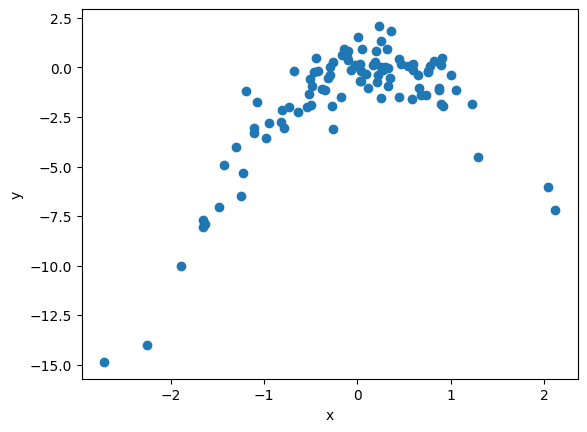

In [14]:
###YOUR ANSWER HERE###
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

# The scatterplot shows a clear curved (parabolic) relationship between x and y. This makes sense because the data were generated from a quadratic model.
# The points are spread around this curve due to the added random noise, but the overall downward-opening quadratic shape is still visible.
# This means that a linear model would not be enough, and a polynomial model of degree at least 2 would be better to see the relationship.


(c)(13 points): Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

- $Y = \beta_0 + \beta_1 X + \varepsilon$ 
- $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon$
- $Y = \beta_0 + \beta_1 X+ \beta_2 X^2+ \beta_3 X^3 + \varepsilon$
- $Y = \beta_0 + \beta_1 X+ \beta_2 X^2+ \beta_3 X^3+ \beta_4 X^4 + \varepsilon$

Note you may find it helpful to use the data.frame() function to create a single data set containing both X and Y .


In [15]:
from sklearn.preprocessing import PolynomialFeatures 

d = 4

X_poly = PolynomialFeatures(degree=d, include_bias=False).fit_transform(x[:,None])

X = pd.DataFrame(X_poly, columns=[f'x^{i}' for i in range(1,d+1)])

y = pd.Series(y)


In [16]:
from sklearn.model_selection import cross_val_score ### (10 points)
from sklearn.model_selection import KFold
##YOUR CODE HERE## (10 points)

from sklearn.preprocessing import PolynomialFeatures

np.random.seed(1)
data = pd.DataFrame({'x': x, 'y': y})
loocv = KFold(n_splits=len(data))
loocv_errors = []

for d in range(1, 5):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(data[['x']])
    
    model = LinearRegression()
    
    mse = -cross_val_score(
        model, X_poly, data['y'],
        cv=loocv,
        scoring='neg_mean_squared_error').mean()
    loocv_errors.append(mse)
loocv_errors

[6.633029839181983, 1.1229368563419673, 1.3017965489358863, 1.3323942694179312]

#### ✅ Question (c): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (c) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

###YOUR ANSWER HERE##

I completed most using my own own knowledge, including understanding polynomial regression, LOOCV, and how to compute mean squared error.
I used external resources only to help with the exact syntax for using cross_val_score with KFold for LOOCV in Python. This helped me structure the code correctly, but the logic and interpretation of the results were done using my own understanding.

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.


In [17]:
### YOUR ANSWER HERE##

# I used generative AI to help me with the syntax for computing LOOCV errors using cross_val_score and KFold in Python,
# particularly for fitting polynomial regression models of degrees 1–4.

# I relied on my prior knowledge of polynomial regression, least squares fitting, LOOCV,
# and mean squared error to interpret the results and explain why the quadratic model best fits the data.

#YOUR PROMPTS##

# “I have a simulated data set with x and y. I want to compute LOOCV errors for polynomial regression models of degree 1 through 4 using scikit-learn in Python.
# Show me how to use cross_val_score with KFold to do this.”

##AI OUTPUTS##

# You can use KFold(n_splits=n) for LOOCV, create polynomial features with PolynomialFeatures, fit a LinearRegression model,
# and use cross_val_score with scoring='neg_mean_squared_error'.
# Loop over degrees 1 to 4, compute negative mean squared error for each, and store the results.”


(d) (4 points): Repeat (c) using another random seed, and report your results.

Are your results the same as what you got in (c)? Why?


In [18]:
##YOUR CODE HERE##

np.random.seed(42)
data = pd.DataFrame({'x': x, 'y': y})
loocv = KFold(n_splits=len(data))

loocv_errors_seed2 = []

for d in range(1, 5):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(data[['x']])
    model = LinearRegression()
    mse = -cross_val_score(
        model,
        X_poly,
        data['y'],
        cv=loocv,
        scoring='neg_mean_squared_error'
    ).mean()
    loocv_errors_seed2.append(mse)
loocv_errors_seed2

[6.633029839181983, 1.1229368563419673, 1.3017965489358863, 1.3323942694179312]

###YOUR COMMENTS HERE###

The LOOCV errors are the same as in part (c). This happens because LOOCV is deterministic, where every observation is left out once, so changing the random seed does not change the folds.


(e) (4 points): Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.


###YOUR ANSWER HERE###

The model with the smallest LOOCV error is the quadratic model: $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon$. This is what I expected. The data were generated from a quadratic relationship, so the degree-2 model matches the structure of the data. The linear model underfits because it cannot capture the curvature. The quadratic model captures the true relationship and therefore has the lowest error. Higher-degree, like 3 and 4, models are more flexible than necessary and can overfit the noise.

*Added part f (16 points):* Repeat part (c) using $k$-fold CV for $k=5,10,15,20$. Plot your results for error vs. degree for all these plus the LOOCV version. What do you notice?


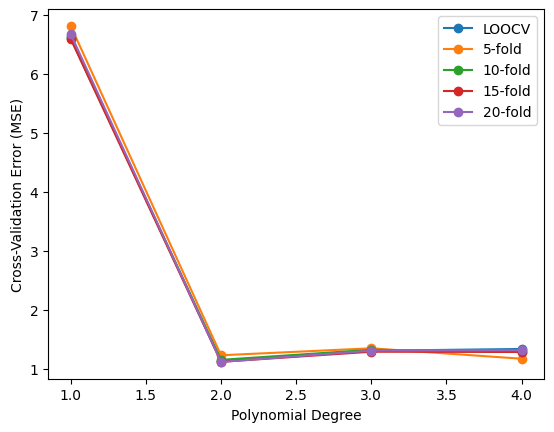

In [19]:
###YOUR CODE HERE## (13 points)

data = pd.DataFrame({'x': x, 'y': y})
degrees = range(1, 5)
k_values = [5, 10, 15, 20]
errors = {}
loocv = KFold(n_splits=len(data))
loocv_errors = []
for d in degrees:
    X_poly = PolynomialFeatures(d, include_bias=False).fit_transform(data[['x']])
    model = LinearRegression()
    mse = -cross_val_score(
        model, X_poly, data['y'],
        cv=loocv,
        scoring='neg_mean_squared_error'
    ).mean()
    loocv_errors.append(mse)
errors['LOOCV'] = loocv_errors
for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=1)
    k_errors = []
    
    for d in degrees:
        X_poly = PolynomialFeatures(d, include_bias=False).fit_transform(data[['x']])
        model = LinearRegression()
        mse = -cross_val_score(
            model, X_poly, data['y'],
            cv=kf,
            scoring='neg_mean_squared_error'
        ).mean()
        k_errors.append(mse)
    errors[f'{k}-fold'] = k_errors
plt.figure()
for label, vals in errors.items():
    plt.plot(degrees, vals, marker='o', label=label)

plt.xlabel("Polynomial Degree")
plt.ylabel("Cross-Validation Error (MSE)")
plt.legend()
plt.show()

# All curves have a similar overall shape, the error decreases from degree 1 to degree 2, then increases for higher degrees.
# The quadratic model (degree 2) has the lowest error across all values of k, including LOOCV.
# LOOCV produces the noisiest curve, with slightly more variation.
# Smaller values of k, like 5-fold CV, produce smoother curves but slightly higher bias.
# As k increases, the curves become more similar to LOOCV.
# There is a bias–variance tradeoff in choosing k: Smaller k: higher bias, lower variance. Larger k: lower bias, higher variance

#### ✅ Question (f): Documenting Your Solution Process (3 points)

Please answer the following clearly and completely:

1. **Prior Knowledge vs. External Resources (1 point)**  
   Indicate which parts of Question (f) you completed using your own prior knowledge, and which parts you completed using external resources (e.g., generative AI, past assignments, Stack Overflow, Google, etc.).

###YOUR ANSWER HERE##

I completed most of it using my own prior knowledge, including understanding k-fold cross-validation, how changing k affects bias and variance, and how to interpret cross-validation error across different model degrees. I used external resources mainly to help with creating the plot that compares error versus polynomial degree for multiple values of k on the same graph. The hardest part for me conceptually in terms of coding was organizing the results from different k-fold values and LOOCV into a structure that could be plotted cleanly and consistently, especially keeping the curves aligned by polynomial degree. Other than help with plotting and organizing the results, the modeling and interpretation were done using my own understanding.

2. **Required Documentation (2 points)**  
   - For any part where you used **generative AI**, you must include the exact prompts you entered and the corresponding AI outputs. **Copy and paste them directly**.  
   - For any part where you used other external resources, list those sources.  
   - For parts completed without external resources, briefly state what prior knowledge you relied on (no detailed explanation required).

Responses that do not include **prompts and AI outputs** (when applicable) will not receive full credit.

In [20]:
### YOUR ANSWER HERE##

# I used generative AI to help me with how to structure the code to plot cross-validation error versus polynomial
# degree for multiple values of k (including LOOCV) on the same graph.

#YOUR PROMPTS##

# “Repeat part (c) using k-fold CV for k = 5, 10, 15, 20. Plot error vs degree for all these plus LOOCV.
# How should I organize the code and make one plot comparing all of them?”
# Example code to refer to

##AI OUTPUTS##

# “You can loop over polynomial degrees and different k values, store the cross-validation errors in a dictionary or list
# and then plot error versus degree for each k on the same figure using matplotlib.
# LOOCV can be handled using KFold with n_splits equal to the number of observations.”

## Forward and backward selection

Below are the training and testing error from doing linear regression on different subsets of the variables from the `auto` data set to predict `mpg`.

| Variables                                    | Train Score | Test Score |
|----------------------------------------------|-------------|------------|
| null model                                   | 60.76       | 60.73      |
| (cylinders,)                                 | 24.02       | 24.15      |
| (horsepower,)                                | 23.94       | 24.19      |
| (weight,)                                    | 18.68       | 18.84      |
| (acceleration,)                              | 49.87       | 50.26      |
| (cylinders, horsepower)                      | 20.85       | 21.13      |
| (cylinders, weight)                          | 18.38       | 18.55      |
| (cylinders, acceleration)                    | 23.94       | 24.38      |
| (horsepower, weight)                         | 17.84       | 18.03      |
| (horsepower, acceleration)                   | 22.46       | 22.70      |
| (weight, acceleration)                       | 18.25       | 18.61      |
| (cylinders, horsepower, weight)              | 17.76       | 17.99      |
| (cylinders, horsepower, acceleration)        | 20.06       | 20.44      |
| (cylinders, weight, acceleration)            | 18.13       | 18.54      |
| (horsepower, weight, acceleration)           | 17.84       | 18.16      |
| (cylinders, horsepower, weight, acceleration)| 17.76       | 18.13      |


- (Parts a, b, and c) (2 + 2 + 2=6 points): For each of the three subset selection methods discussed in class ((a) best subset selection, (b) forward selection, and (c) backward selection), do the following 
  - Describe the steps taken in the algorithm to arrive at a conclusion for the best possible model. 
  - Be sure to say what $M_k$ is for $k= 0 , 1, \cdots, 4$. 
  - What is the best model returned by the algorithm? 
  - How many models do you have to train to arrive at the conclusion? 
- (d)(2 points): Are your answers to (a), (b), and (c) the same? Do we expect them to be? 

*Note that I am not assuming you need to code any of these options, you only need to calculate by hand.*


- (a) best subset selection

#YOUR ANSWER HERE##

How the algorithm works:
* Consider all possible subsets of the predictors.
* For each subset size $k=0,1,2,3,4$, fit every model that contains exactly k predictors.
* For each k, choose the model $M_k$ with the lowest test error.
Compare each model and select the model with the smallest test error overall.

Models $M_k$ (using test error):
* $M_0$: null model (60.73)
* $M_1$: (weight) (18.84)
* $M_2$: (horsepower, weight) (18.03)
* $M_3$: (cylinders, horsepower, weight) (17.99)
* $M_4$: (cylinders, horsepower, weight, acceleration) (18.13)

Best model returned:
(cylinders, horsepower, weight)
 
Number of models trained:
With 4 predictors, best subset selection fits $2^4=16$ models.

- (b) forward selection

###YOUR ANSWER HERE###

How the algorithm works:
* Start with the null model (no predictors).
* At each step, add one predictor that results in the largest decrease in test error when combined with the predictors already in the model.
* Continue adding predictors until all variables are included.
* Among the models considered at each step, select the model with the lowest test error.

Models $M_k$ (based on the forward path and test error):
* $M_0$: null model
* $M_1$: (weight) (best single predictor with lowest test error = 18.84)
* $M_2$: (horsepower, weight)
(lowest test error among models that add one variable to $M_1$)
* $M_3$: (cylinders, horsepower, weight) (best three-variable model along the forward path)
* $M_4$: (cylinders, horsepower, weight, acceleration)

Best model returned: (cylinders, horsepower, weight)

How many models are trained?
* Step 1: 4 models
* Step 2: 3 models
* Step 3: 2 models
* Step 4: 1 model

10 models

- (c) backward selection

###YOUR ANSWER HERE###

How the algorithm works:
* Start with the full model containing all predictors.
* At each step, remove one predictor whose removal leads to the smallest increase or largest decrease in test error.
* Continue removing predictors until only the null model remains.
* Among the models considered at each step, choose the one with the lowest test error.

Models $M_k$ (following the backward path and test error):
* $M_4$: (cylinders, horsepower, weight, acceleration)
* $M_3$: (cylinders, horsepower, weight)(dropping acceleration gives the lowest test error = 17.99)
* $M_2$: (horsepower, weight)
* $M_1$: (weight)
* $M_0$: null model

Best model returned: (cylinders, horsepower, weight)

How many models are trained?
* Step 1: 4 models (each variable removed once)
* Step 2: 3 models
* Step 3: 2 models
* Step 4: 1 model

10 models

- (d) Are your answers to (a), (b), and (c) the same? Do we expect them to be? 

###YOUR ANSWER HERE###

Yes, the answers to parts (a), (b), and (c) are the same. All three methods select the model (cylinders, horsepower, weight). In general, we do not expect these methods to always give the same result. Best subset selection considers all possible models, while forward and backward selection are greedy methods that only explore a limited set of models. In this case, because there are only a few predictors and one model clearly performs best, all three methods happen to agree.